In [3]:
import pandas as pd
import numpy as np


In [4]:
from google.colab import files
uploaded=files.upload()


Saving web-page-phishing.csv to web-page-phishing.csv


In [5]:
data=pd.read_csv("web-page-phishing.csv")
data.head()

,url_length,n_dots,n_hypens,n_underline,n_slash,n_questionmark,n_equal,n_at,n_and,n_exclamation,n_space,n_tilde,n_comma,n_plus,n_asterisk,n_hastag,n_dollar,n_percent,n_redirection,phishing
0,37,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,77,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1
2,126,4,1,2,0,1,3,0,2,0,0,0,0,0,0,0,0,0,1,1
3,18,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
4,55,2,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


In [6]:
data.shape

(100077, 20)

In [7]:
data.columns

Index(['url_length', 'n_dots', 'n_hypens', 'n_underline', 'n_slash',
       'n_questionmark', 'n_equal', 'n_at', 'n_and', 'n_exclamation',
       'n_space', 'n_tilde', 'n_comma', 'n_plus', 'n_asterisk', 'n_hastag',
       'n_dollar', 'n_percent', 'n_redirection', 'phishing'],
      dtype='object')

In [8]:
data.describe()


,url_length,n_dots,n_hypens,n_underline,n_slash,n_questionmark,n_equal,n_at,n_and,n_exclamation,n_space,n_tilde,n_comma,n_plus,n_asterisk,n_hastag,n_dollar,n_percent,n_redirection,phishing
count,100077.000000,100077.000000,100077.000000,100077.000000,100077.000000,100077.000000,100077.000000,100077.000000,100077.000000,100077.000000,100077.000000,100077.000000,100077.000000,100077.000000,100077.000000,100077.000000,100077.000000,100077.000000,100077.000000,100077.000000
mean,39.177683,2.224397,0.405188,0.137724,1.135386,0.024391,0.215834,0.022143,0.143330,0.002608,0.004876,0.003617,0.002378,0.002468,0.004097,0.000450,0.001899,0.109286,0.361532,0.363340
std,47.971847,1.255046,1.285465,0.723995,1.828526,0.167789,0.959802,0.268393,0.913656,0.082207,0.144569,0.078500,0.079558,0.104382,0.284046,0.058028,0.097412,1.695327,0.775492,0.480964
min,4.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,0.000000
25%,18.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,24.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,44.000000,2.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,4165.000000,24.000000,43.000000,21.000000,44.000000,9.000000,23.000000,43.000000,26.000000,10.000000,18.000000,5.000000,11.000000,19.000000,60.000000,13.000000,10.000000,174.000000,17.000000,1.000000


In [9]:
data.isnull().sum()

,0
url_length,0
n_dots,0
n_hypens,0
n_underline,0
n_slash,0
n_questionmark,0
n_equal,0
n_at,0
n_and,0
n_exclamation,0


In [10]:
X=data.drop("phishing",axis=1)
Y=data["phishing"]
X.head()
Y.head()

,phishing
0,0
1,1
2,1
3,0
4,0


In [11]:
from sklearn.model_selection import train_test_split

In [12]:
from numpy.random.mtrand import random
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [13]:
X_train.shape
X_test.shape

(20016, 19)

In [14]:
from sklearn.ensemble import RandomForestClassifier

In [15]:
model=RandomForestClassifier()

In [16]:
model.fit(X_train,Y_train)

RandomForestClassifier()

In [17]:
Y_pred=model.predict(X_test)

In [18]:
from sklearn.metrics import accuracy_score

In [19]:
accuracy=accuracy_score(Y_test,Y_pred)

In [20]:
print("Accuracy:",accuracy)

Accuracy: 0.8924860111910472


In [22]:
print(Y_pred[:10])
print(Y_test[:10])

[1 1 1 0 0 0 0 0 0 1]
67531    1
89539    0
84639    1
149      0
7646     0
39684    0
74549    0
1332     0
51122    0
69584    1
Name: phishing, dtype: int64


In [23]:
import pickle
pickle.dump(model, open("phishing_model.pk1","wb"))

In [21]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(Y_test,Y_pred)
print(cm)

[[11726   972]
 [ 1180  6138]]


In [24]:
from sklearn.metrics import classification_report
print(classification_report(Y_test,Y_pred))

              precision    recall  f1-score   support

           0       0.91      0.92      0.92     12698
           1       0.86      0.84      0.85      7318

    accuracy                           0.89     20016
   macro avg       0.89      0.88      0.88     20016
weighted avg       0.89      0.89      0.89     20016



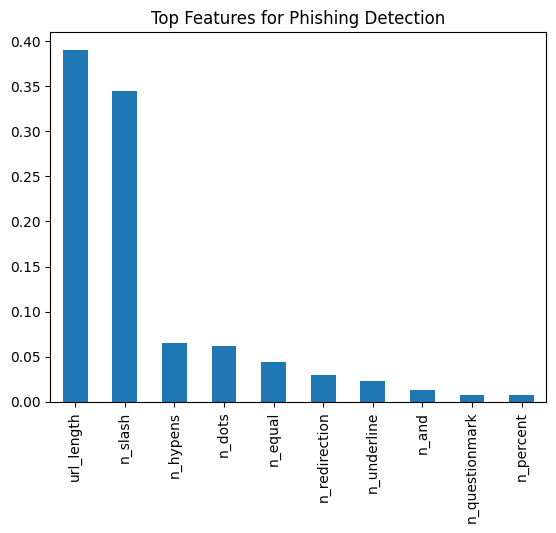

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
feature_importance = pd.Series(model.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Features for Phishing Detection")
plt.show()